# Task 4 - Churn Prediction Model
**Project:** Customer Churn Analysis and Prediction &nbsp;|&nbsp; **Organisation:** Saiket Systems - Data Analysis Internship
**Task:** Task 4 of 4 &nbsp;|&nbsp; **Prepared by:** [Your Name] &nbsp;|&nbsp; **Date:** October 2026
**Dataset:** Telco Customer Churn (7,043 customers, 21 columns)

**Objective.** Build machine-learning models that predict which customers will churn, evaluate them with appropriate metrics, and show how the result can be used to prioritise retention effort.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
SEED = 42
PAL = {"No": "#4C78A8", "Yes": "#E45756"}

# Locate the project root whether this notebook sits in /notebooks or in the root folder
HERE = Path.cwd()
ROOT = next((p for p in [HERE, HERE.parent] if (p / "data" / "raw").exists()), HERE)
RAW = ROOT / "data" / "raw" / "Telco_Customer_Churn_Dataset_.csv"
PROCESSED = ROOT / "data" / "processed"; PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES = ROOT / "outputs" / "figures"; FIGURES.mkdir(parents=True, exist_ok=True)
TABLES = ROOT / "outputs" / "tables"; TABLES.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.savefig(FIGURES / name, dpi=150, bbox_inches="tight")

print("Project root:", ROOT)

Project root: /home/claude/telco-churn-project


In [2]:
CLEAN = PROCESSED / "telco_churn_cleaned.csv"
assert CLEAN.exists(), "Cleaned data not found - run Notebook 01 (data cleaning) first."
df = pd.read_csv(CLEAN)
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
print("Loaded cleaned data:", df.shape)

Loaded cleaned data: (7043, 22)


In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve, precision_recall_curve, classification_report,
                             ConfusionMatrixDisplay)

ENC = PROCESSED / "telco_churn_encoded.csv"
assert ENC.exists(), "Encoded data not found - run Notebook 01 first."
enc = pd.read_csv(ENC)
X = enc.drop(columns=["customerID", "Churn"]); y = enc["Churn"]
print("Features:", X.shape, "| churn rate:", round(y.mean(), 4))

Features: (7043, 23) | churn rate: 0.2654


## 1. Train / test split
80% of customers are used for training and 20% are held back for testing. The split is **stratified**, so both parts keep the same ~26.5% churn share, and the random seed is fixed for reproducibility.

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"Train {X_tr.shape} | Test {X_te.shape} | churn share train {y_tr.mean():.3f} / test {y_te.mean():.3f}")
print(f"Baseline accuracy (always predict 'no churn'): {1 - y_te.mean():.3f}")

Train (5634, 23) | Test (1409, 23) | churn share train 0.265 / test 0.265
Baseline accuracy (always predict 'no churn'): 0.735


**Why accuracy is not enough.** Only about 27% of customers churn, so a "model" that predicts *no one* will churn is already 73.5% accurate and is useless for retention. The models are therefore judged mainly on **precision** (of the customers flagged, how many really churn), **recall** (of the customers who churn, how many were caught), **F1** and **ROC-AUC**.

## 2. Train and compare models

In [5]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEED)),
    "Logistic Regression (balanced)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    "Random Forest (balanced)": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
}
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
rows, fitted, probs = [], {}, {}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    p = m.predict_proba(X_te)[:, 1]; pred = (p >= 0.5).astype(int)
    fitted[name], probs[name] = m, p
    rows.append({"Model": name, "Accuracy": accuracy_score(y_te, pred), "Precision": precision_score(y_te, pred),
                 "Recall": recall_score(y_te, pred), "F1": f1_score(y_te, pred), "ROC-AUC": roc_auc_score(y_te, p),
                 "CV ROC-AUC (train)": cross_val_score(m, X_tr, y_tr, cv=cv, scoring="roc_auc").mean()})
results = pd.DataFrame(rows).set_index("Model").round(3)
results.to_csv(TABLES / "model_comparison.csv")
results

,Accuracy,Precision,Recall,F1,ROC-AUC,CV ROC-AUC (train)
Model,,,,,,
Logistic Regression,0.807,0.659,0.564,0.608,0.842,0.846
Logistic Regression (balanced),0.739,0.505,0.781,0.613,0.841,0.846
Random Forest (balanced),0.774,0.557,0.733,0.633,0.844,0.845
Gradient Boosting,0.798,0.655,0.508,0.572,0.842,0.847


**Findings.** The four models perform almost identically on ROC-AUC (about 0.84). That suggests the available features carry a fixed amount of predictive signal, and a more complex algorithm does not extract more of it. **Logistic regression** is therefore chosen as the main model because it is as accurate as the others and is **interpretable**: its coefficients show which factors raise or lower risk. The balanced variants catch more churners (recall 0.73-0.78) but flag many more customers wrongly (precision 0.51-0.56). This is a trade-off, explored in section 5.

Note that the random-forest and gradient-boosting results can shift slightly between library versions and machines.

## 3. Evaluate the main model (logistic regression, threshold 0.5)

              precision    recall  f1-score   support

    Retained       0.85      0.89      0.87      1035
     Churned       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



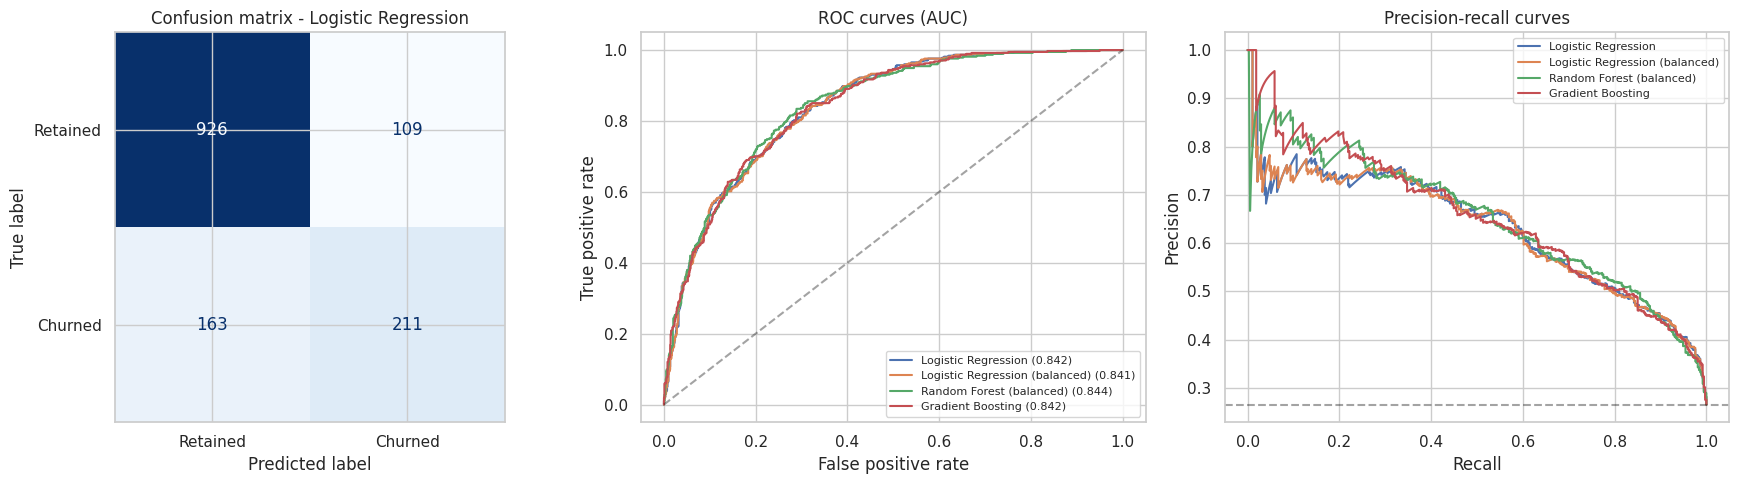

In [6]:
MAIN = "Logistic Regression"
pred = (probs[MAIN] >= 0.5).astype(int)
print(classification_report(y_te, pred, target_names=["Retained", "Churned"]))

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay(confusion_matrix(y_te, pred), display_labels=["Retained", "Churned"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title(f"Confusion matrix - {MAIN}")
for name in models:
    fpr, tpr, _ = roc_curve(y_te, probs[name]); ax[1].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_te, probs[name]):.3f})")
ax[1].plot([0, 1], [0, 1], "k--", alpha=.4); ax[1].set_title("ROC curves (AUC)"); ax[1].set_xlabel("False positive rate"); ax[1].set_ylabel("True positive rate"); ax[1].legend(fontsize=8, loc="lower right")
for name in models:
    pr, rc, _ = precision_recall_curve(y_te, probs[name]); ax[2].plot(rc, pr, label=name)
ax[2].axhline(y_te.mean(), color="k", ls="--", alpha=.4); ax[2].set_title("Precision-recall curves"); ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision"); ax[2].legend(fontsize=8)
plt.tight_layout(); savefig("model_01_evaluation.png"); plt.show()

**Reading the confusion matrix (test set, 1,409 customers).** Of 374 customers who actually churned, the model caught **211** (recall 0.56) and missed 163. Of 320 customers it flagged, 211 really churned (precision 0.66) and 109 did not. Accuracy is 80.7% against a 73.5% do-nothing baseline.

## 4. Which factors drive churn?

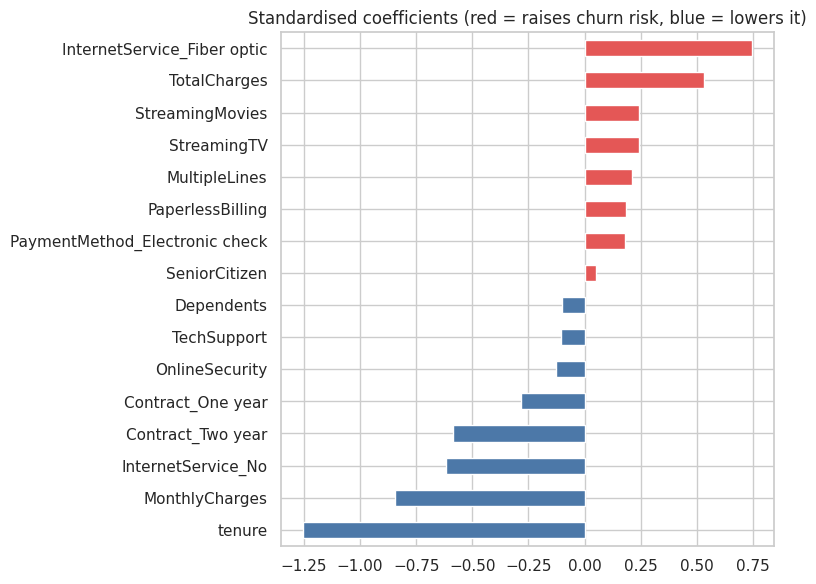

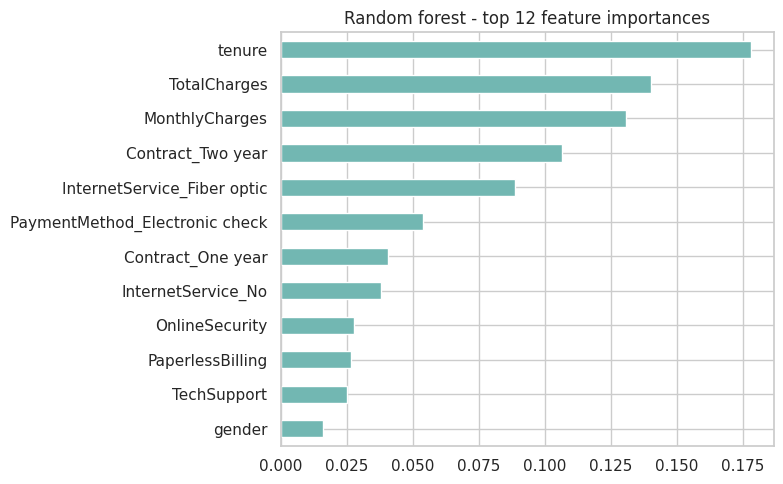

In [7]:
coefs = pd.Series(fitted[MAIN][-1].coef_[0], index=X.columns).sort_values()
top = pd.concat([coefs.head(8), coefs.tail(8)])
plt.figure(figsize=(8, 6))
top.plot.barh(color=["#4C78A8" if v < 0 else "#E45756" for v in top])
plt.title("Standardised coefficients (red = raises churn risk, blue = lowers it)")
plt.tight_layout(); savefig("model_02_coefficients.png"); plt.show()

rf = fitted["Random Forest (balanced)"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(12)
plt.figure(figsize=(8, 5)); imp.plot.barh(color="#72B7B2"); plt.title("Random forest - top 12 feature importances")
plt.tight_layout(); savefig("model_03_rf_importance.png"); plt.show()

**Findings.** Both models agree on the main drivers: **tenure** and **contract length** protect against churn (longer tenure and two-year contracts lower risk), while **fiber-optic internet** and **higher total charges** raise it. Streaming add-ons and electronic-check payment also push risk up.

**Caution when reading coefficients.** `MonthlyCharges` has a *negative* coefficient. This does not mean that higher bills reduce churn. It overlaps strongly with `TotalCharges`, fiber and the add-on services, so its effect is shared among them. Coefficients should be read as a group, and they show association, not cause.

## 5. Choosing the decision threshold
By default a customer is flagged when the predicted probability is at least 0.5. For churn this is rarely ideal: **lowering the threshold catches more churners but contacts more customers who would have stayed.**

,precision,recall,F1,flagged_customers
threshold,,,,
0.10,0.406,0.947,0.569,871
0.15,0.440,0.917,0.595,779
0.20,0.468,0.858,0.606,686
0.25,0.498,0.810,0.617,608
0.30,0.519,0.754,0.615,543
0.35,0.544,0.709,0.616,487
0.40,0.567,0.668,0.613,441
0.45,0.601,0.615,0.608,383
0.50,0.659,0.564,0.608,320


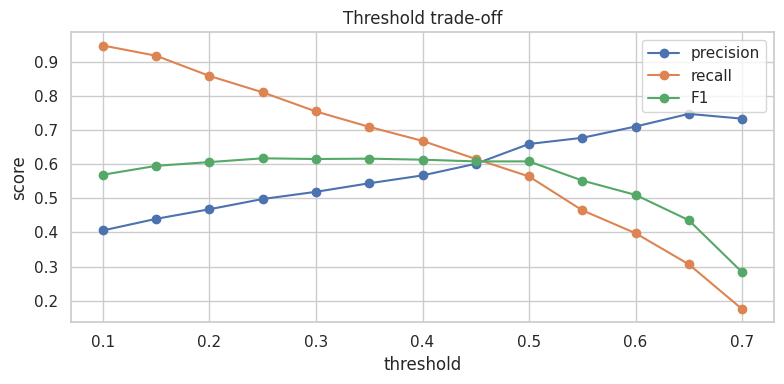

In [8]:
thr_rows = []
for t in np.arange(0.10, 0.71, 0.05):
    pr_ = (probs[MAIN] >= t).astype(int)
    thr_rows.append({"threshold": round(t, 2), "precision": precision_score(y_te, pr_), "recall": recall_score(y_te, pr_),
                     "F1": f1_score(y_te, pr_), "flagged_customers": int(pr_.sum())})
thr = pd.DataFrame(thr_rows).set_index("threshold").round(3)
thr.to_csv(TABLES / "threshold_tradeoff.csv")
display(thr)
thr[["precision", "recall", "F1"]].plot(figsize=(8, 4), marker="o"); plt.title("Threshold trade-off"); plt.ylabel("score")
plt.tight_layout(); savefig("model_04_threshold.png"); plt.show()

**Findings.** F1 is almost flat between thresholds 0.25 and 0.45 (about 0.61). Within that range the choice is a business decision, not a statistical one. For example, at **0.30** the model flags 543 test customers and catches 75% of churners (precision 0.52), while at **0.50** it flags only 320 and catches 56% (precision 0.66).

### Illustrative cost model
The right threshold depends on what a retention offer costs and what a saved customer is worth. **No cost data is provided in the dataset, so the figures below are illustrative assumptions only**, and should be replaced with real company numbers. The useful result is the *method*: a campaign breaks even when the precision of the flagged group exceeds `offer cost / (value saved x success rate)`.

In [9]:
def net_value(t, cost, value, success):
    flagged = probs[MAIN] >= t
    tp = (flagged & (y_te == 1)).sum()
    return tp * success * value - flagged.sum() * cost

scenarios = {                       # (offer cost, value of a saved customer, offer success rate)  -- ILLUSTRATIVE
    "Cheap offer ($20, $300 value, 30% success)": (20, 300, 0.30),
    "Mid offer ($50, $300 value, 30% success)":   (50, 300, 0.30),
    "Costly offer ($100, $300 value, 20% success)": (100, 300, 0.20),
}
rows = []
for name, (c, v, s) in scenarios.items():
    nv = pd.Series({round(t, 2): net_value(t, c, v, s) for t in np.arange(0.05, 0.9, 0.05)})
    rows.append({"scenario": name, "break-even precision": round(c / (v * s), 2),
                 "best threshold": nv.idxmax(), "net value at best": round(nv.max()),
                 "net value at 0.50": round(net_value(0.5, c, v, s))})
pd.DataFrame(rows).set_index("scenario")

,break-even precision,best threshold,net value at best,net value at 0.50
scenario,,,,
"Cheap offer ($20, $300 value, 30% success)",0.22,0.15,15290,12590
"Mid offer ($50, $300 value, 30% success)",0.56,0.50,2990,2990
"Costly offer ($100, $300 value, 20% success)",1.67,0.85,-40,-19340


**Reading this.** The cheaper and more effective the offer is, the lower the best threshold, because it pays to contact more customers. If an offer is expensive or rarely works (third scenario), no threshold makes the campaign profitable (net value is negative or near zero everywhere), so the model could not justify a broad campaign. This is why the cost inputs must come from the business.

## 6. Hyperparameter tuning (logistic regression)

In [10]:
grid = GridSearchCV(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED)),
    param_grid={"logisticregression__C": [0.01, 0.1, 1, 10, 100],
                "logisticregression__class_weight": [None, "balanced"]},
    scoring="roc_auc", cv=cv, n_jobs=-1)
grid.fit(X_tr, y_tr)
print("Best params:", grid.best_params_, "| CV ROC-AUC:", round(grid.best_score_, 4))
print("Test ROC-AUC with best params:", round(roc_auc_score(y_te, grid.predict_proba(X_te)[:, 1]), 4))

Best params: {'logisticregression__C': 10, 'logisticregression__class_weight': None} | CV ROC-AUC: 0.8463
Test ROC-AUC with best params: 0.8411


Tuning gives no meaningful improvement (test AUC about 0.841, the same as the untuned model). The default logistic regression is already near the ceiling for these features, so it is kept as the final model.

## 7. Honest scoring of every customer (out-of-fold)
To score *every* customer without scoring anyone with a model that has already seen them, 5-fold **out-of-fold** predictions are used: each customer's score comes from a model that was trained on the other four folds.

Out-of-fold ROC-AUC: 0.845


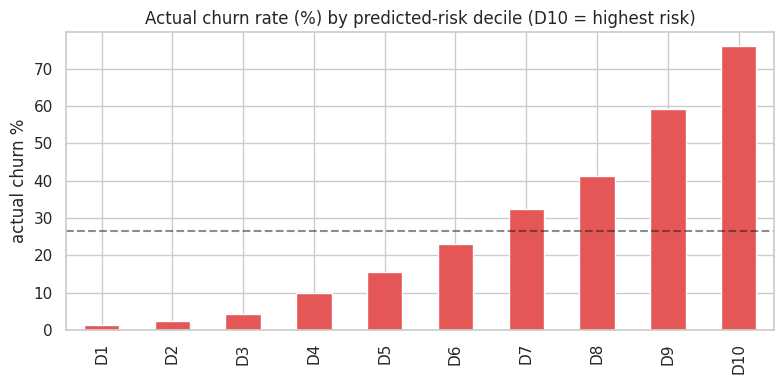

Top 20% highest-risk customers: actual churn 67.6% (vs 26.5% overall) and they contain 51.0% of all churners


,customerID,churn_probability,Contract,InternetService,tenure,MonthlyCharges,TotalCharges,Churn,risk_decile
1976,9497-QCMMS,0.8620,Month-to-month,Fiber optic,1,93.55,93.55,Yes,10
4800,9300-AGZNL,0.8616,Month-to-month,Fiber optic,1,94.00,94.00,Yes,10
3749,4424-TKOPW,0.8587,Month-to-month,Fiber optic,2,93.85,196.75,Yes,10
6368,2720-WGKHP,0.8582,Month-to-month,Fiber optic,2,94.00,181.70,Yes,10
3380,5178-LMXOP,0.8476,Month-to-month,Fiber optic,1,95.10,95.10,Yes,10
997,1374-DMZUI,0.8442,Month-to-month,Fiber optic,4,94.30,424.45,Yes,10
2208,7216-EWTRS,0.8426,Month-to-month,Fiber optic,1,100.80,100.80,Yes,10
301,8098-LLAZX,0.8418,Month-to-month,Fiber optic,4,95.45,396.10,Yes,10
2577,4910-GMJOT,0.8339,Month-to-month,Fiber optic,1,94.60,94.60,Yes,10
3159,5150-ITWWB,0.8313,Month-to-month,Fiber optic,3,94.85,335.75,No,10


In [11]:
oof = cross_val_predict(models[MAIN], X, y, cv=cv, method="predict_proba")[:, 1]
print("Out-of-fold ROC-AUC:", round(roc_auc_score(y, oof), 4))

scores = enc[["customerID"]].assign(churn_probability=oof.round(4)).merge(
    df[["customerID", "Contract", "InternetService", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]], on="customerID")
scores.to_csv(TABLES / "churn_risk_scores.csv", index=False)

# Decile lift: customers ranked by predicted risk, split into 10 equal groups
scores["risk_decile"] = pd.qcut(scores.churn_probability.rank(method="first"), 10, labels=range(1, 11))
lift = scores.assign(c=(scores.Churn == "Yes").astype(int)).groupby("risk_decile", observed=True).c.mean().mul(100).round(1)
lift.index = [f"D{i}" for i in lift.index]
ax = lift.plot.bar(color="#E45756", figsize=(8, 4)); ax.axhline(y.mean()*100, color="k", ls="--", alpha=.5)
ax.set_title("Actual churn rate (%) by predicted-risk decile (D10 = highest risk)"); ax.set_ylabel("actual churn %")
plt.tight_layout(); savefig("model_05_decile_lift.png"); plt.show()

top20 = scores[scores.churn_probability >= scores.churn_probability.quantile(0.8)]
print(f"Top 20% highest-risk customers: actual churn {(top20.Churn=='Yes').mean():.1%} "
      f"(vs {y.mean():.1%} overall) and they contain {(top20.Churn=='Yes').sum() / y.sum():.1%} of all churners")
scores.sort_values("churn_probability", ascending=False).head(10)

**Findings.** The model ranks customers well. Actual churn climbs from about **1%** in the lowest-risk decile to about **76%** in the highest. The top 20% of customers by predicted risk churn at **67.6%** (2.5x the base rate) and contain **51%** of all churners. A retention team that can only contact one customer in five would therefore reach about half of the at-risk customers.

## 8. Is the model well calibrated?

In [12]:
scores["actual"] = (scores.Churn == "Yes").astype(int)
cal = scores.groupby("Contract").agg(customers=("actual", "size"), predicted=("churn_probability", "mean"), actual=("actual", "mean")).round(3)
display(cal)

scores["tenure_band"] = pd.cut(scores.tenure, [-1, 12, 24, 48, 72], labels=["0-12", "13-24", "25-48", "49-72"])
cal2 = scores.groupby(["Contract", "tenure_band"], observed=True).agg(
    customers=("actual", "size"), predicted=("churn_probability", "mean"), actual=("actual", "mean")).round(3)
cal2

,customers,predicted,actual
Contract,,,
Month-to-month,3875,0.427,0.427
One year,1473,0.113,0.113
Two year,1695,0.029,0.028


customers  predicted  actual
Contract       tenure_band                              
Month-to-month 0-12              1994      0.489   0.514
               13-24              737      0.429   0.377
               25-48              802      0.345   0.329
               49-72              342      0.256   0.260
One year       0-12               124      0.151   0.105
               13-24              197      0.115   0.081
               25-48              518      0.116   0.106
               49-72              634      0.103   0.129
Two year       0-12                68      0.057   0.000
               13-24               90      0.039   0.000
               25-48              274      0.030   0.022
               49-72             1263      0.026   0.033

**Findings.** Averaged by contract type the predictions are close to reality (month-to-month 42.7% predicted vs 42.7% actual; two-year 2.9% vs 2.8%). In the smallest groups the model is less exact. For example, new two-year customers get about 5.7% predicted against 0% observed, but those groups have fewer than 100 customers.

## 9. What-if tool: score a single customer
Describe a customer and get a predicted churn probability. Because predictions for combinations the data barely contains are unreliable, the tool also reports **how many similar customers exist in the data** and what their actual churn rate was.

In [13]:
BINARY_COLS = ["SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling",
               "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
OHE_COLS = ["InternetService", "Contract", "PaymentMethod"]

def encode(frame):               # identical to the encoding in Notebook 01
    e = frame.drop(columns=["customerID"], errors="ignore").copy()
    if "Churn" in e: e["Churn"] = e["Churn"].map({"Yes": 1, "No": 0})
    e["gender"] = e["gender"].map({"Female": 0, "Male": 1})
    for c in BINARY_COLS: e[c] = e[c].map({"No": 0, "Yes": 1})
    return pd.get_dummies(e, columns=OHE_COLS, drop_first=True, dtype=int)

final = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEED)).fit(X, y)
BANDS = [-1, 12, 24, 48, 72]

def predict_customer(cust):
    row = pd.DataFrame([cust])
    full = pd.concat([df.drop(columns=["ChurnFlag", "Churn", "customerID"]), row], ignore_index=True)
    e = encode(full.assign(Churn="No")).drop(columns="Churn").iloc[[-1]][X.columns]
    prob = final.predict_proba(e)[0, 1]
    band = pd.cut([cust["tenure"]], BANDS)[0]
    similar = df[(df.Contract == cust["Contract"]) & (df.InternetService == cust["InternetService"]) &
                 (pd.cut(df.tenure, BANDS) == band)]
    return prob, len(similar), similar.ChurnFlag.mean() if len(similar) else float("nan")

customer = {
    "gender": "Female", "SeniorCitizen": "No", "Partner": "No", "Dependents": "No",
    "tenure": 3, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes", "StreamingMovies": "Yes",
    "Contract": "Month-to-month", "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.0, "TotalCharges": 285.0,
}
out = []
for contract in ["Month-to-month", "One year", "Two year"]:
    p, k, actual = predict_customer({**customer, "Contract": contract})
    out.append({"contract": contract, "predicted_churn": f"{p:.1%}", "similar_customers_in_data": k,
                "their_actual_churn": f"{actual:.1%}" if k else "no data"})
pd.DataFrame(out).set_index("contract")

,predicted_churn,similar_customers_in_data,their_actual_churn
contract,,,
Month-to-month,75.7%,916,70.2%
One year,61.5%,7,28.6%
Two year,44.1%,0,no data


**Reading this.** For the example customer (new, fiber, electronic check, streaming) the month-to-month prediction is supported by hundreds of similar customers. The one-year and two-year rows are **not**: very few or no similar customers exist, so those predictions are extrapolations and should not be quoted as findings. The tool also shows association, not what would happen if a customer were actually moved onto a longer contract, because customers who choose long contracts differ from those who do not.

## Summary of Task 4
| Item | Result |
|---|---|
| Final model | Logistic regression (standardised features, 80/20 stratified split) |
| Test performance @ 0.50 | Accuracy 0.807, precision 0.66, recall 0.56, F1 0.61, **ROC-AUC 0.842** |
| Do-nothing baseline | Accuracy 0.735 |
| Model choice | All four models reach AUC about 0.84, so the interpretable one was chosen |
| Main churn drivers | Short tenure, month-to-month contract, fiber optic, high total charges, electronic check |
| Ranking power | Top 20% by risk contain 51% of churners (67.6% churn rate, 2.5x the base) |
| Calibration | Close to actual by contract type; weaker in very small groups |
| Threshold | A business decision: 0.30 catches 75% of churners at 0.52 precision |

**Limitations.** The model uses a single snapshot of customers, so it cannot tell *when* someone will leave. It shows association, not cause. The cost model uses illustrative numbers. Performance would need to be monitored on new data over time.